In [1]:
from inspectre import Inspectre, ray_sampling
import numpy as np
from scipy import integrate as it
import matplotlib.pyplot as plt
from scipy.interpolate import InterpolatedUnivariateSpline as IUS
from scipy.interpolate import CubicSpline
import tqdm

In [2]:
a = 0.5
p = 10.0
e = 0.2
x = 1
mass = 1.0
err = 1e-15
mode="equatorial"

insp = Inspectre(
    spin=a,
    semilatus_rectum=p,
    eccentricity=e,
    x=x,
    mass=mass,
    err=err,
    mode=mode
)

In [3]:
print(f"""Orbital parameters: 
Energy \t\t = {insp.energy},
Angular momentum = {insp.angular_momentum},
Carter constant  = {insp.carter_constant}""")
print()
print(f"""Frequencies: 
Azimuthal: \t = {insp.omega_phi},
Radial:  \t = {insp.omega_r},
Polar: \t\t = {insp.omega_theta}""")

Orbital parameters: 
Energy 		 = 0.9554917116351583,
Angular momentum = 3.5965610903774414,
Carter constant  = -2.5847692791459328e-15

Frequencies: 
Azimuthal: 	 = 0.029689018630018806,
Radial:  	 = 0.021370474208095996,
Polar: 		 = 0.0


In [4]:
N=14
insp.generate_equatorial_trajectory(num_pts=2**N)

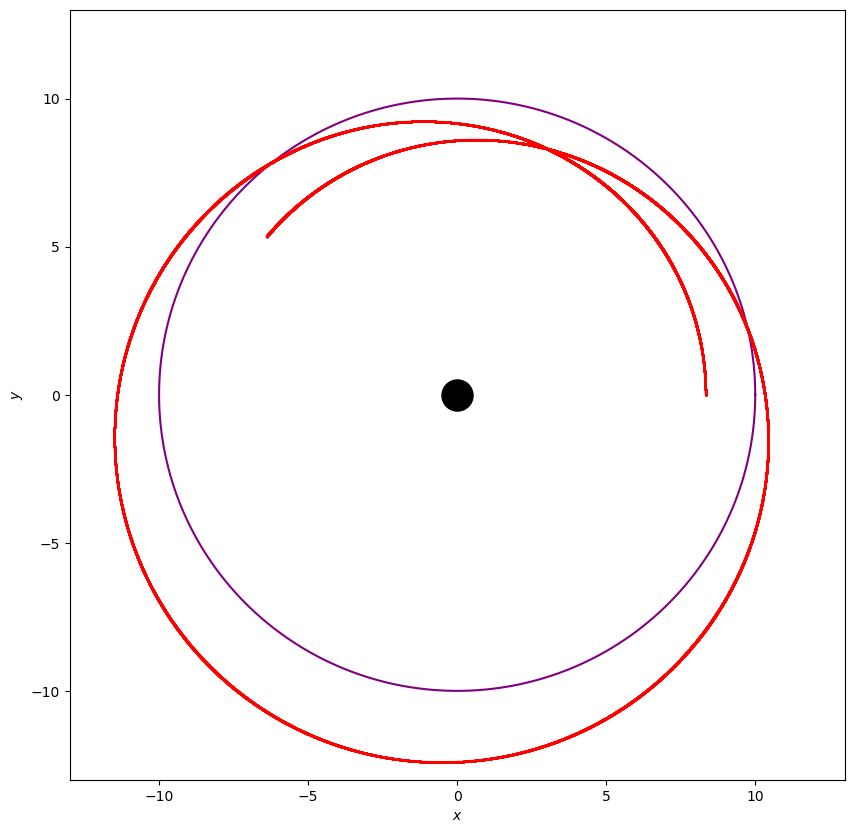

In [5]:
plt.figure(figsize=(10,10))
rField = 10.

r_p = insp.trajectory["r"]
phi_p = insp.trajectory["phi"]
t = insp.trajectory["t"]

rmax = np.max([10, np.max(r_p)])*1.04
plt.plot(r_p*np.cos(phi_p), r_p*np.sin(phi_p),c='k',alpha=0.4)
plt.scatter(r_p*np.cos(phi_p), r_p*np.sin(phi_p), s=1,zorder=10,c='r')
plt.scatter(0,0, s=500, c='k')

plot_thetas = np.linspace(0,2*np.pi,num=1000)
plt.plot(rField*np.cos(plot_thetas), rField*np.sin(plot_thetas), c='purple')

tidx = np.argmin(np.abs(t-235.75))
# plt.scatter(r_p[tidx]*np.cos(phi_p[tidx]),r_p[tidx]*np.sin(phi_p[tidx]),c='r',s=100,zorder=100,marker='x')

plt.xlim(-rmax, rmax)
plt.ylim(-rmax, rmax)
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.show()

## convergence

In [6]:
src_mn = insp.source_mn_integrand_along_trajectory(2, 1, 10.0, 1.5701, full_traj=False)

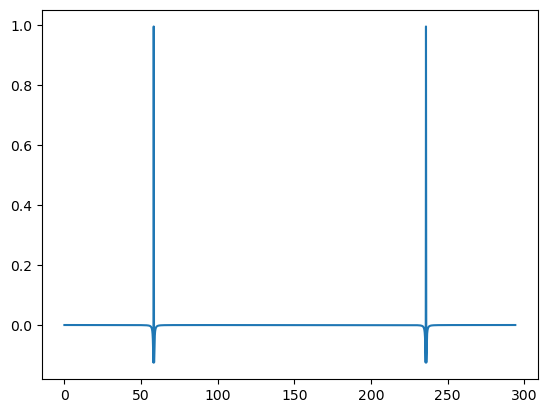

In [7]:
plt.plot(src_mn.T[0], src_mn.T[1])
plt.show()

In [8]:
spdata = IUS(src_mn.T[0], src_mn.T[1], k=3).integral(0.0,src_mn.T[0][-1])
sim_lam = it.simpson(src_mn.T[1], x=src_mn.T[0])
tra_lam = np.trapezoid(src_mn.T[1], x=src_mn.T[0])
print(spdata)
print(sim_lam)
print(tra_lam)

0.015912704950836243
0.015912705038275146
0.01591270509942521


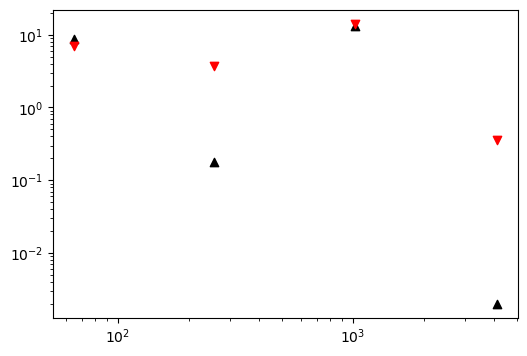

In [9]:
plt.figure(figsize=(6,4))
for i in [6, 8, 10, 12]:
    insp.generate_equatorial_trajectory(num_pts=2**i)
    src_mn = insp.source_mn_integrand_along_trajectory(2, 1, 10., 1.5701)
    
    tres = src_mn.T[0]
    le = len(tres)
    trapz = np.trapezoid(src_mn.T[1], x=tres)
    simps = it.simpson(src_mn.T[1], x=tres)
    trapz_rs = 1.0 - trapz / spdata
    simps_rs = 1.0 - simps / spdata
    plt.scatter(le, abs(trapz_rs), marker='^', c='k')
    plt.scatter(le, abs(simps_rs), marker='v', c='r')

plt.yscale('log')
plt.xscale('log')
plt.show()

In [10]:
insp.generate_equatorial_trajectory(num_pts=2**N)
insp.resample_trajectory(num_pts=2**N)

In [11]:
src_mn = insp.source_mn_integrand_along_trajectory(2, 1, 10., 1.5701)

In [12]:
spdata_uni = IUS(src_mn.T[0], src_mn.T[1], k=3).integral(0,src_mn.T[0][-1])
sim_lam_uni = it.simpson(src_mn.T[1], x=src_mn.T[0])
tra_lam_uni = np.trapezoid(src_mn.T[1], x=src_mn.T[0])
print(spdata_uni)
print(sim_lam_uni)
print(tra_lam_uni)

0.015912705018586635
0.015912704616141176
0.015912705018586652


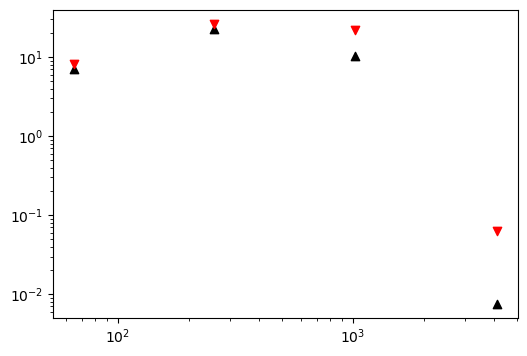

In [13]:
plt.figure(figsize=(6,4))
for i in [6, 8, 10, 12]:
    insp.generate_equatorial_trajectory(num_pts=2**i)
    insp.resample_trajectory(num_pts=2**i)
    src_mn = insp.source_mn_integrand_along_trajectory(2, 1, 10., 1.5701)
    
    tres = src_mn.T[0]
    le = len(tres)
    trapz = np.trapezoid(src_mn.T[1], x=tres)
    simps = it.simpson(src_mn.T[1], x=tres)
    trapz_rs = 1.0 - trapz / spdata_uni
    simps_rs = 1.0 - simps / spdata_uni
    plt.scatter(le, abs(trapz_rs), marker='^', c='k')
    plt.scatter(le, abs(simps_rs), marker='v', c='r')

plt.yscale('log')
plt.xscale('log')
plt.show()

## elliptic

In [34]:
a = 0.5
p = 10.0
e = 0.2
x = 1
mass = 1.0
err = 1e-15
mode="equatorial"

insp_short = Inspectre(
    spin=a,
    semilatus_rectum=p,
    eccentricity=e,
    x=x,
    mass=mass,
    err=err,
    mode=mode
)

insp_long = Inspectre(
    spin=a,
    semilatus_rectum=p,
    eccentricity=e,
    x=x,
    mass=mass,
    err=err,
    mode=mode
)

insp_short.generate_equatorial_trajectory(num_pts = 2**10)
insp_short.resample_trajectory(num_pts=2**10, indep_var="t")
insp_long.generate_equatorial_trajectory(num_pts = 2**14)
insp_long.resample_trajectory(num_pts=2**14, indep_var="t")

# rays_in_xy = ray_sampling(p, e, delta_mu=0.1,delta_nu = np.pi/10)
rays_in_xy = np.array([[r,th] for r in np.linspace(7.5,13.5,num=12) for th in np.linspace(np.pi/2-0.19, np.pi/2+0.2, num=11)])

In [36]:
data = []

for r, th in tqdm.tqdm(rays_in_xy):
    src_short = insp_short.source_mn_integrand_along_trajectory(2, 1, r, th)
    src_long = insp_long.source_mn_integrand_along_trajectory(2, 1, r, th)

    tra_short = np.trapezoid(src_short.T[1], x=src_short.T[0])
    tra_long = np.trapezoid(src_long.T[1], x=src_long.T[0])
    si_short = it.simpson(src_short.T[1], x=src_short.T[0])
    si_long = it.simpson(src_long.T[1], x=src_long.T[0])
    spdata_short = IUS(src_short.T[0], src_short.T[1], k=3).integral(0.0,src_short.T[0][-1])
    spdata_long = IUS(src_long.T[0], src_long.T[1], k=3).integral(0.0,src_long.T[0][-1])
    data.append([r, x, tra_short, tra_long, si_short, si_long, spdata_short, spdata_long])

data = np.array(data)

100%|██████████| 132/132 [22:42<00:00, 10.32s/it]


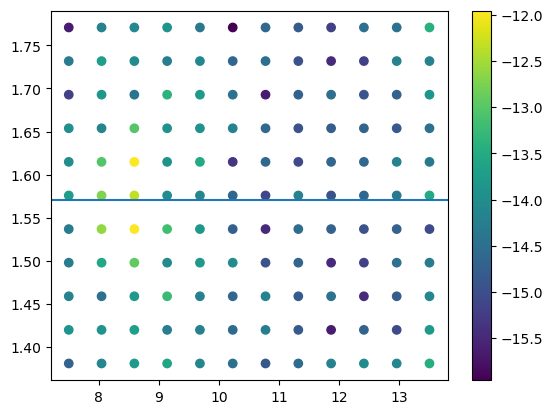

In [40]:
plt.scatter(rays_in_xy[:,0], rays_in_xy[:,1], c=np.log10(np.abs(1.0 - data.T[-5]/data.T[-1])))
plt.axhline(y=np.pi/2)
plt.colorbar()
plt.show()